In [1]:
import geopandas as gpd
from shapely.wkt import loads

from ezgrid import grid, irregular

## Example
This notebook demonstrates how to use the package ezgrid to generate sampling points within a polygon.
Three different methods are used to generate the sampling points: optimized grid, optimized coverage, and random sampling.

<Axes: >

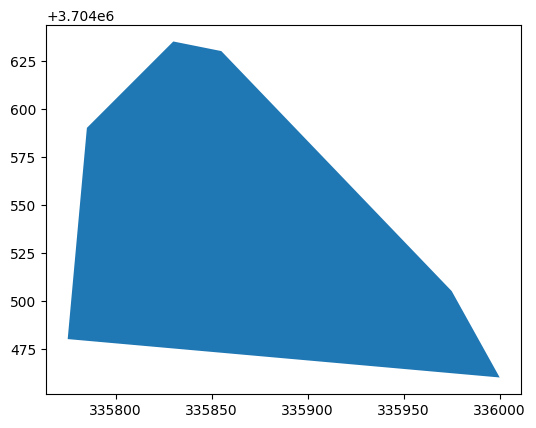

In [2]:
# Load example polygon
example_polygon = "POLYGON ((335855.00000000006 3704630, 335974.99999999936 3704504.999999999, 335999.99999999924 3704459.999999999, 335775 3704480.0000000005, 335785 3704589.9999999995, 335829.9999999992 3704635.0000000005, 335855.00000000006 3704630))"
example_polygon_crs = 'EPSG:32616'
polygon = loads(example_polygon)
field = gpd.GeoDataFrame({'geometry': [polygon]}, crs=example_polygon_crs)
field.plot()

<Axes: >

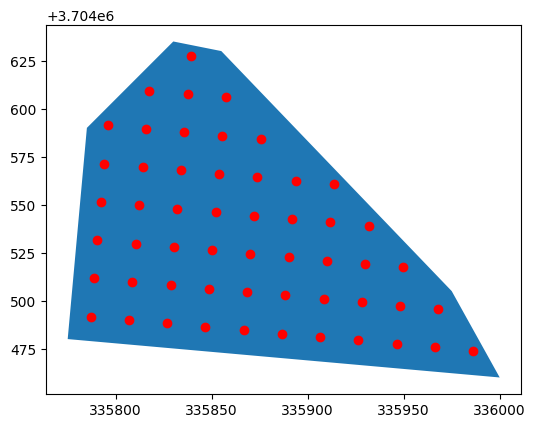

In [3]:
# Optimized grid (aligned with the polygon longest side and positioned to maximize the number of points inside the polygon)
grid_optf = grid.optimized_grid(field, points_dist=20, min_dist_edges=5, n_trials=200)
ax = field.plot()
grid_optf.plot(ax=ax, color='red')

<Axes: >

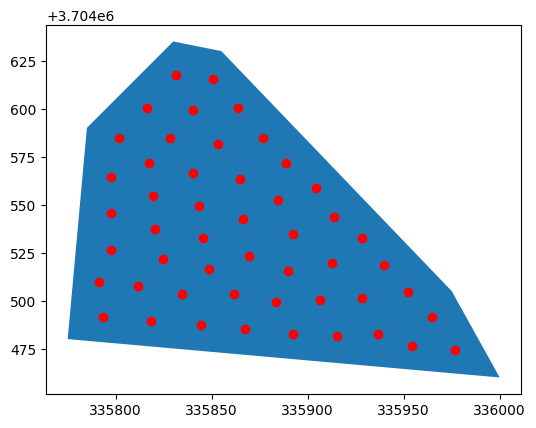

In [4]:
# Points are optimized to ensure optimal coverage of the polygon
points = irregular.optimize_coverage(field, n_points=50, min_dist_edges=5, resolution=1)
ax = field.plot()
points.plot(ax=ax, color='red')

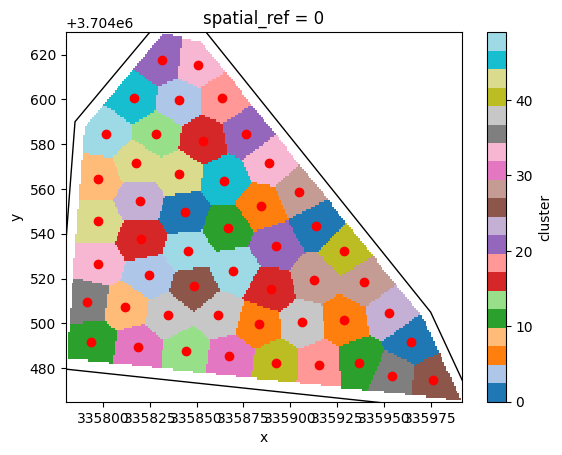

In [5]:
# Demonstration of how points are optimized to ensure optimal coverage of the polygon.
# Kmeans clustering is used to cluster areas that can be represented by a point.
points, polygon_clusters_raster = irregular.optimize_coverage(field, n_points=50, min_dist_edges=5, resolution=1, debug=True)
ax = field.plot(color='none', edgecolor='black')
ax = points.plot(ax=ax, color='red')
polygon_clusters_raster.plot.imshow(ax=ax, cmap='tab20')

<Axes: >

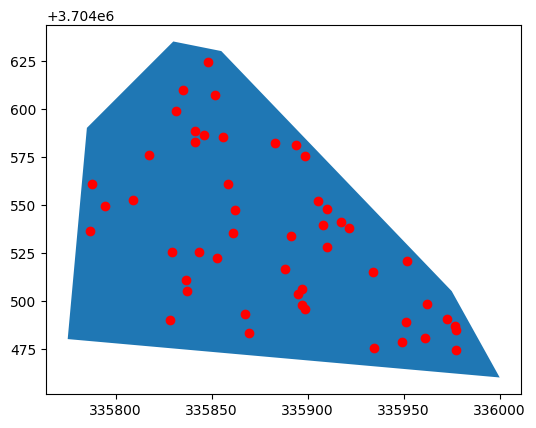

In [8]:
# Random sampling of points inside the polygon
points = irregular.random_sampling(field, n_points=50, min_dist_edges=5)
ax = field.plot()
points.plot(ax=ax, color='red')